# STV Senate Bubble Plots

In [1]:
import matplotlib.pyplot as plt
import jsonlines
import numpy as np

In [2]:
def bubble_plot_integer(ax, data, labels, colors, title, marker =".", size = 1000):
    # create figure
    # fig, ax = plt.subplots() #plt.figure()
    
    x_max = int(max(max(vector) for vector in data))
    bin_min = 0
    bin_max = x_max
    bins = np.arange(bin_min-.5, bin_max+1.5, 1)
    
    for j, vector in enumerate(data):
        x = [i for i in range(x_max+1)] # x=0,...,x_max
        y = [j+1]*len(x) # put each vector at a different height
        
        bin_heights, bin_edges = np.histogram(vector, bins = bins,density=True)
        circle_areas = [size*bin_heights[i] for i in range(x_max+1)]
        ax.scatter(x, y, s=circle_areas, alpha=1, color = colors[j], label = None, edgecolors='black', marker=marker)

    # Add labels and title
    ax.set_xticks([i for i in range(x_max+1)])
    ax.set_yticks([i+1 for i in range(len(data))], labels)
    ax.set_xlim((-2, x_max+2))
    ax.set_ylim((0.5, len(data)+.5))
    ax.set_title(title)
    
    return ax

In [3]:
model_to_color = {"plackett-luce": '#D2691E', "bradley-terry": '#E32636', "cambridge": '#FFBF00', 'combined': '#8DB600', 
                  #"SB":"#09FCEE", "IC":"#1A7601","IAC":"#929292"
                  }

In [8]:
num_plans = 5
level = "senate"
district_setting = "0-0-8"
num_districts = 8
num_simulations = 100
optimize = "neutral"

data_sets = {"racial-basic":{}, 
        "racial-w90c60":{},
        "racial-w60c90":{},
        }
for current_parameters in data_sets:

    models = ["plackett-luce", "bradley-terry", "cambridge"]

    plan_model_total_seat_counts = {plan_idx:{model:[] for model in models} for plan_idx in range(1, num_plans+1)}
    for plan_num in range(1,num_plans+1):
        with jsonlines.open(f'/Users/cdonnay/Documents/GitHub/MGGG/Massachusetts-RCV/output/records/mass_stv_outputs/massachusetts-{district_setting}-{current_parameters}/{optimize}-{plan_num}.jsonl') as reader:
            data = [obj for obj in reader]

            for model in models:
                # observations of poc seat wins for a fixed model and plan across the districts
                plan_model_total_seat_counts[plan_num][model] = [sum(model_data["pocwins"][i] for district_data in data for model_data in district_data if model_data["model"] == model) for i in range(num_simulations)]
            
    # now you can concatenate over all plans
    model_total_seat_counts = {model: [seat_count for plan_idx in range(1, num_plans+1) for seat_count in plan_model_total_seat_counts[plan_idx][model]] for model in models}

    # and compute combined
    model_total_seat_counts["combined"] = [seat_count for model_seat_counts in model_total_seat_counts.values() for seat_count in model_seat_counts]

    data_sets[current_parameters] = model_total_seat_counts

In [9]:
print(data_sets)

{'racial-basic': {'plackett-luce': [20, 19, 20, 17, 22, 18, 19, 19, 23, 18, 19, 22, 21, 20, 18, 18, 18, 20, 23, 21, 20, 20, 19, 19, 19, 20, 19, 21, 22, 18, 19, 20, 20, 21, 21, 18, 19, 19, 20, 20, 22, 19, 20, 17, 19, 18, 17, 20, 19, 22, 19, 21, 20, 18, 20, 18, 18, 19, 17, 21, 22, 19, 20, 20, 19, 20, 19, 18, 23, 21, 21, 21, 18, 20, 19, 22, 21, 21, 22, 20, 20, 19, 19, 18, 21, 19, 19, 20, 19, 20, 19, 20, 19, 19, 18, 19, 21, 18, 19, 18, 22, 21, 20, 21, 19, 20, 20, 20, 20, 22, 18, 18, 20, 20, 19, 17, 18, 21, 22, 19, 20, 19, 21, 22, 21, 21, 21, 19, 20, 22, 19, 20, 23, 19, 20, 20, 20, 20, 21, 21, 19, 21, 21, 19, 20, 19, 19, 21, 17, 18, 23, 17, 20, 19, 19, 19, 19, 19, 23, 20, 20, 22, 20, 19, 20, 18, 21, 20, 18, 19, 20, 20, 17, 19, 18, 19, 19, 21, 19, 19, 20, 19, 20, 19, 21, 19, 21, 21, 20, 20, 21, 19, 18, 20, 17, 19, 18, 17, 18, 21, 18, 19, 18, 19, 19, 21, 16, 19, 18, 19, 19, 17, 18, 18, 18, 17, 24, 20, 21, 22, 22, 18, 20, 20, 19, 22, 20, 23, 21, 20, 20, 20, 17, 21, 18, 19, 19, 18, 19, 19, 19, 

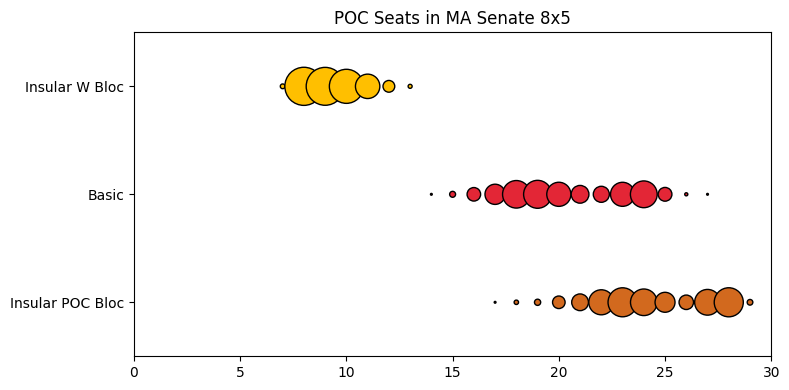

In [30]:
fig, ax =  plt.subplots(figsize=(8,4))
data_order = ["racial-w60c90", "racial-basic", "racial-w90c60",]
data = [data_sets[x]["combined"] for x in data_order]
labels = ["Insular POC Bloc", "Basic", "Insular W Bloc",]

colors = ["#D2691E", "#E32636", "#FFBF00"]
# data = [seat_counts for seat_counts in model_total_seat_counts.values()][::-1]
# labels = [model for model in model_total_seat_counts.keys()][::-1]
# colors = [model_to_color[l] for l in labels]
ax = bubble_plot_integer(ax, data , labels, colors, "POC Seats in MA Senate 8x5", size = 10000)

ax.set_xlim(0, 30)
ax.set_xticks([i for i in range(0,35, 5)])
plt.tight_layout()
plt.savefig("MA_new_america_stv_senate_poc_seats_polarization_toggles.png", dpi=300)


# Testing

In [11]:
num_plans = 5
level = "senate"
district_setting = "0-0-8"
num_districts = 8
num_simulations = 100
current_parameters = "racial-basic"
optimize = "neutral"

models = ["plackett-luce", "bradley-terry", "cambridge"]

plan_model_total_seat_counts = {plan_idx:{model:[] for model in models} for plan_idx in range(1, num_plans+1)}
#for plan_num in range(1,num_plans+1):
plan_num = 1
with jsonlines.open(f'/Users/cdonnay/Documents/GitHub/MGGG/Massachusetts-RCV/output/records/mass_stv_outputs/massachusetts-{district_setting}-{current_parameters}/{optimize}-{plan_num}.jsonl') as reader:
    data = [obj for obj in reader]

    for model in models:
        # observations of poc seat wins for a fixed model and plan across the districts
        plan_model_total_seat_counts[plan_num][model] = [sum(model_data["pocwins"][i] for district_data in data for model_data in district_data if model_data["model"] == model) for i in range(num_simulations)]
        
# now you can concatenate over all plans
model_total_seat_counts = {model: [seat_count for plan_idx in range(1, 2) for seat_count in plan_model_total_seat_counts[plan_idx][model]] for model in models}

# and compute combined
model_total_seat_counts["combined"] = [seat_count for model_seat_counts in model_total_seat_counts.values() for seat_count in model_seat_counts]

In [12]:
for model in models+["combined"]:
    print(model)
    print("min", "max")
    print(min(model_total_seat_counts[model]), max(model_total_seat_counts[model]))
    print()

plackett-luce
min max
17 23

bradley-terry
min max
15 21

cambridge
min max
21 25

combined
min max
15 25



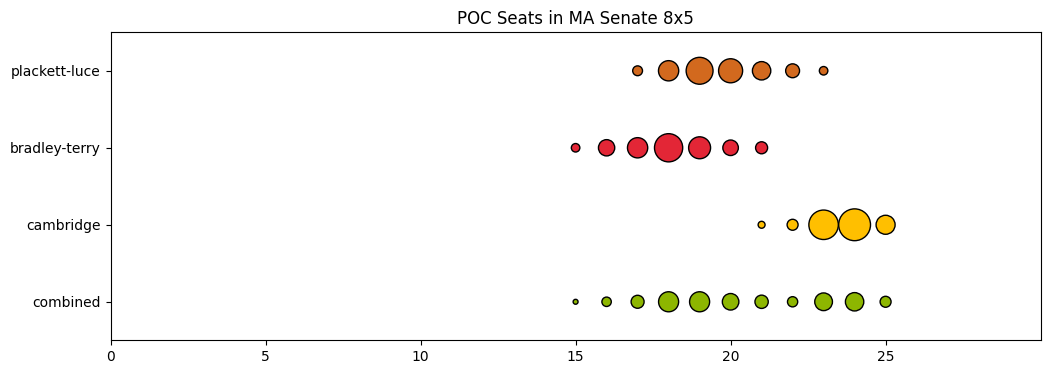

In [13]:
fig, ax =  plt.subplots(figsize=(12,4))
data = [seat_counts for seat_counts in model_total_seat_counts.values()][::-1]
labels = [model for model in model_total_seat_counts.keys()][::-1]
colors = [model_to_color[l] for l in labels]
ax = bubble_plot_integer(ax, data , labels, colors, "POC Seats in MA Senate 8x5", size = 5000)

ax.set_xlim(0, 30)
ax.set_xticks([i for i in range(0,30, 5)])
plt.show()

# TODO add different proportionality ticks 